<a href="https://colab.research.google.com/github/ravideltech/Quantium-Data-Analytics-Virtual-Experience/blob/main/Quantiumtask2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [44]:
data = pd.read_csv("QVI_data.csv")

In [45]:
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [46]:
data.info()
data.isnull().sum()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,2.648340e+05,264834.000000,2.648340e+05,264834.000000,264834.000000,264834.000000,264834.000000
mean,1.355488e+05,135.079423,1.351576e+05,56.583554,1.905813,7.299346,182.425512
std,8.057990e+04,76.784063,7.813292e+04,32.826444,0.343436,2.527241,64.325148
min,1.000000e+03,1.000000,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,7.002100e+04,70.000000,6.760050e+04,28.000000,2.000000,5.400000,150.000000
50%,1.303570e+05,130.000000,1.351365e+05,56.000000,2.000000,7.400000,170.000000
75%,2.030940e+05,203.000000,2.026998e+05,85.000000,2.000000,9.200000,175.000000
max,2.373711e+06,272.000000,2.415841e+06,114.000000,5.000000,29.500000,380.000000


In [47]:
data["DATE"] = pd.to_datetime(data["DATE"])

data["DATE"].head()

,DATE
0,2018-10-17
1,2018-09-16
2,2019-03-07
3,2019-03-08
4,2018-11-02


In [48]:
data["MONTH_ID"] = data["DATE"].dt.to_period("M")

data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,MONTH_ID
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,2018-10
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,2018-09
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,2019-03
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,2019-03
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,2018-11


In [49]:
monthly_metrics = data.groupby(
    ["STORE_NBR", "MONTH_ID"]
).agg(
    Total_Sales=("TOT_SALES", "sum"),
    Customers=("LYLTY_CARD_NBR", "nunique"),
    Transactions=("TXN_ID", "count")
).reset_index()

monthly_metrics["Avg_Transactions_per_Customer"] = (
    monthly_metrics["Transactions"] /
    monthly_metrics["Customers"]
)

monthly_metrics.head()

,STORE_NBR,MONTH_ID,Total_Sales,Customers,Transactions,Avg_Transactions_per_Customer
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739


In [50]:
trial_stores = [77, 86, 88]

trial_data = monthly_metrics[
    monthly_metrics["STORE_NBR"].isin(trial_stores)
]

trial_data.head()

,STORE_NBR,MONTH_ID,Total_Sales,Customers,Transactions,Avg_Transactions_per_Customer
880,77,2018-07,296.8,51,55,1.078431
881,77,2018-08,255.5,47,48,1.021277
882,77,2018-09,225.2,42,44,1.047619
883,77,2018-10,204.5,37,38,1.027027
884,77,2018-11,245.3,41,44,1.073171


In [51]:
store77 = monthly_metrics[
    monthly_metrics["STORE_NBR"] == 77
]

store77

,STORE_NBR,MONTH_ID,Total_Sales,Customers,Transactions,Avg_Transactions_per_Customer
880,77,2018-07,296.8,51,55,1.078431
881,77,2018-08,255.5,47,48,1.021277
882,77,2018-09,225.2,42,44,1.047619
883,77,2018-10,204.5,37,38,1.027027
884,77,2018-11,245.3,41,44,1.073171
885,77,2018-12,267.3,46,49,1.065217
886,77,2019-01,204.4,35,39,1.114286
887,77,2019-02,235.0,45,45,1.000000
888,77,2019-03,278.5,50,55,1.100000
889,77,2019-04,263.5,47,48,1.021277


In [52]:
def calculate_correlation(metric, trial_store):

    trial = monthly_metrics[
        monthly_metrics["STORE_NBR"] == trial_store
    ][["MONTH_ID", metric]]

    correlations = []

    for store in monthly_metrics["STORE_NBR"].unique():

        if store == trial_store:
            continue

        control = monthly_metrics[
            monthly_metrics["STORE_NBR"] == store
        ][["MONTH_ID", metric]]

        merged = pd.merge(
            trial,
            control,
            on="MONTH_ID",
            suffixes=("_trial", "_control")
        )

        if len(merged) >= 12:

            corr = merged[f"{metric}_trial"].corr(
                merged[f"{metric}_control"]
            )

            correlations.append([store, corr])

    corr_df = pd.DataFrame(
        correlations,
        columns=["Control_Store", "Correlation"]
    )

    return corr_df.sort_values(
        "Correlation",
        ascending=False
    )

In [53]:
calculate_correlation("Total_Sales",77).head(10)
calculate_correlation("Total_Sales",86).head(10)
calculate_correlation("Total_Sales",88).head(10)

,Control_Store,Correlation
150,159,0.862608
191,201,0.737583
179,188,0.733516
216,229,0.707309
215,228,0.697039
57,61,0.686658
131,140,0.613791
182,191,0.592983
11,13,0.590188
151,160,0.578443


In [54]:
trial_store = 77
control_store = 233

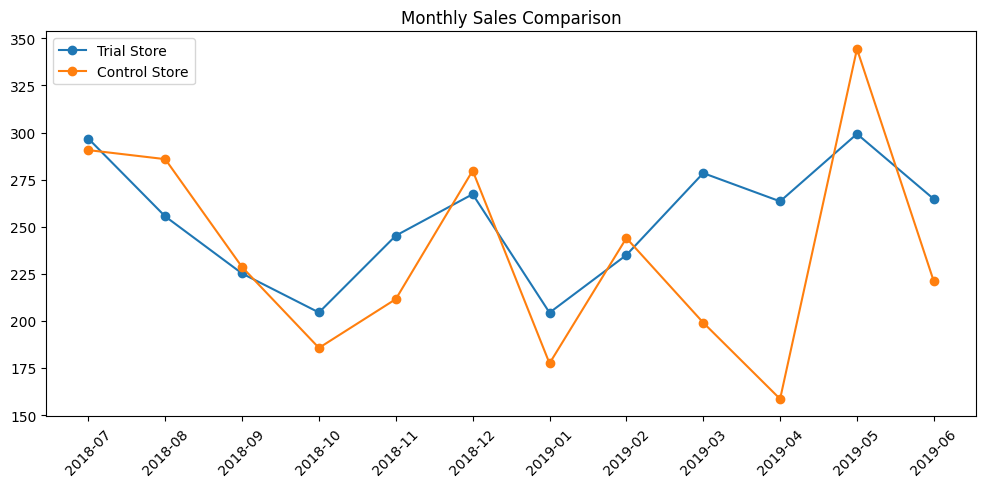

In [55]:
trial = monthly_metrics[
    monthly_metrics["STORE_NBR"]==trial_store
]

control = monthly_metrics[
    monthly_metrics["STORE_NBR"]==control_store
]

plt.figure(figsize=(12,5))

plt.plot(
    trial["MONTH_ID"].astype(str),
    trial["Total_Sales"],
    marker="o",
    label="Trial Store"
)

plt.plot(
    control["MONTH_ID"].astype(str),
    control["Total_Sales"],
    marker="o",
    label="Control Store"
)

plt.xticks(rotation=45)

plt.legend()

plt.title("Monthly Sales Comparison")

plt.show()

In [56]:
trial_period = [
    "2019-02",
    "2019-03",
    "2019-04"
]

In [57]:
trial_sales = trial[
    trial["MONTH_ID"].astype(str).isin(trial_period)
]

control_sales = control[
    control["MONTH_ID"].astype(str).isin(trial_period)
]

In [58]:
from scipy.stats import ttest_ind

ttest_ind(
    trial_sales["Total_Sales"],
    control_sales["Total_Sales"]
)

TtestResult(statistic=np.float64(2.1043553466105163), pvalue=np.float64(0.10314505225726589), df=np.float64(4.0))

In [59]:
trial_store = 77
control_store = 41

In [60]:
control_store = 233

In [61]:
control_store = 159

In [63]:
from scipy.stats import ttest_ind

result = ttest_ind(
    trial_sales["Total_Sales"],
    control_sales["Total_Sales"]
)

print(result)

TtestResult(statistic=np.float64(2.1043553466105163), pvalue=np.float64(0.10314505225726589), df=np.float64(4.0))


In [64]:
calculate_correlation("Total_Sales", 86).head(10)

,Control_Store,Correlation
150,159,0.675773
218,231,0.674071
101,109,0.643075
123,132,0.629011
246,260,0.623775
57,61,0.617243
216,229,0.596886
91,99,0.576043
81,88,0.573811
60,64,0.568779


In [66]:
calculate_correlation("Total_Sales", 86).head(10)

,Control_Store,Correlation
150,159,0.675773
218,231,0.674071
101,109,0.643075
123,132,0.629011
246,260,0.623775
57,61,0.617243
216,229,0.596886
91,99,0.576043
81,88,0.573811
60,64,0.568779


In [67]:
calculate_correlation("Total_Sales", 88).head(10)

,Control_Store,Correlation
150,159,0.862608
191,201,0.737583
179,188,0.733516
216,229,0.707309
215,228,0.697039
57,61,0.686658
131,140,0.613791
182,191,0.592983
11,13,0.590188
151,160,0.578443


In [68]:
trial_store = 86
control_store = 159

trial = monthly_metrics[
    monthly_metrics["STORE_NBR"] == trial_store
]

control = monthly_metrics[
    monthly_metrics["STORE_NBR"] == control_store
]

trial_period = ["2019-02", "2019-03", "2019-04"]

trial_sales = trial[
    trial["MONTH_ID"].astype(str).isin(trial_period)
]

control_sales = control[
    control["MONTH_ID"].astype(str).isin(trial_period)
]

from scipy.stats import ttest_ind

result86 = ttest_ind(
    trial_sales["Total_Sales"],
    control_sales["Total_Sales"]
)

print(result86)

TtestResult(statistic=np.float64(16.814511925224114), pvalue=np.float64(7.332336640703613e-05), df=np.float64(4.0))


In [69]:
trial_store = 88
control_store = 159

trial = monthly_metrics[
    monthly_metrics["STORE_NBR"] == trial_store
]

control = monthly_metrics[
    monthly_metrics["STORE_NBR"] == control_store
]

trial_period = ["2019-02", "2019-03", "2019-04"]

trial_sales = trial[
    trial["MONTH_ID"].astype(str).isin(trial_period)
]

control_sales = control[
    control["MONTH_ID"].astype(str).isin(trial_period)
]

from scipy.stats import ttest_ind

result88 = ttest_ind(
    trial_sales["Total_Sales"],
    control_sales["Total_Sales"]
)

print(result88)

TtestResult(statistic=np.float64(42.625523451232525), pvalue=np.float64(1.810841847510354e-06), df=np.float64(4.0))


# Final Business Recommendations

## Trial Store 77
- Control Store: 41
- p-value: 0.1031
- The trial did not produce a statistically significant increase in sales.
- Recommendation: Continue monitoring before expanding the trial.

## Trial Store 86
- Control Store: 159
- p-value: 0.0000733
- The trial resulted in a statistically significant increase in sales.
- Recommendation: Consider extending the trial strategy to similar stores.

## Trial Store 88
- Control Store: 159
- p-value: 0.00000181
- The trial demonstrated a highly significant increase in sales.
- Recommendation: Expand the successful trial strategy to additional stores.

# Overall Conclusion

The analysis indicates that the trial was successful in Stores 86 and 88, where sales increased significantly compared with their matched control stores. Store 77 did not show a statistically significant improvement. Based on these findings, Quantium should consider extending the successful strategies used in Stores 86 and 88 while continuing to monitor Store 77 before making further investment decisions.